In [1]:
import os
os.getcwd()
# print(os.getcwd())

'/Users/neil'

In [2]:
import pandas as pd
trips = pd.read_csv("trips_2025.csv")
# trips = pd.read_csv("trips_2025.csv", nrows=10)
trips.shape
print(trips.shape)
# print(trips.head())
# # trips.sample(5)
# # trips.head().shape
# # len(trips.head())
# # trips.loc[0]                       # label-based one row or col - range end inclusive 
# # trips.loc[0:1]                 # label-based one row or col - range end inclusive 
# trips.loc[:,'trip_id'] 
# trips.loc[:,['trip_id','start_station_id']] 
# # trips.iloc[0:5]                    # integer-position-based rows – range end exclusive 
# trips.iloc[:,0:2]
# trips.iloc[:,[0,3]]			         # not a range

(250600, 8)


In [3]:
# # trips[trips["rider_type"] == "member"]
# # trips[trips["start_station_id"] == "S06"]
# trips[trips["start_station_id"] == "S99"]
# trips[(trips["rider_type"] == "member") & (trips["bike_type"] == "electric")]
# len(trips[(trips["rider_type"] == "member") & (trips["bike_type"] == "electric")])

In [4]:
# trips.duplicated()
# trips.duplicated().sum()      # 600
# trips.duplicated(keep='first').sum() # default keep='first'
# trips.duplicated(keep=False).sum() # every single instance of a duplicate row
# # trips[trips.duplicated(keep='first')] 
# # trips[trips.duplicated(keep=False)]
# # trips[trips.duplicated(keep=False)].sort_values("trip_id")
# # trips[trips.duplicated(keep=False)].sort_values("trip_id").head(6)
# trips.drop_duplicates() # keeps the first copy by default
# print(trips.shape)
# # trips = trips.drop_duplicates() # keeps the first copy by default
trips.drop_duplicates(subset=None,keep='first',inplace=True) # keep='first','last',False => all
print(trips.shape)   
# trips

(250000, 8)


In [5]:
# trips[trips["start_station_id"] != "S99"]
# print(trips[trips["start_station_id"] != "S99"].shape)
# # trips=trips[trips["start_station_id"] != "S99"]
# # print(trips.shape)
# # trips=trips[trips["start_station_id"].isin(["S99"])]
# # print(trips.shape)
trips=trips[~trips["start_station_id"].isin(["S99"])]
print(trips.shape)

(249737, 8)


In [6]:
# trips["rider_type"].value_counts()
trips["rider_type"] = trips["rider_type"].str.strip().str.lower()
trips["rider_type"].value_counts()   

rider_type
member    158377
casual     91360
Name: count, dtype: int64

In [7]:
# trips["start_station_name"]
# trips["start_station_name"].value_counts()
# print(trips["start_station_name"].nunique()) 
# trips["start_station_name"] = trips["start_station_name"].str.strip().str.title() # capitalize
trips["start_station_name"] = trips["start_station_name"].str.strip().str.title().str.replace('Ut', 'UT', n=-1) # n=-1 -> replaces all occurrences
# trips["start_station_name"] = (
#     trips["start_station_name"].str.strip().str.title()
#   )
# trips["start_station_name"].value_counts()
print(trips["start_station_name"].nunique()) 

24


In [8]:
trips.info()

<class 'pandas.DataFrame'>
Index: 249737 entries, 0 to 250599
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   trip_id             249737 non-null  str  
 1   start_time          249737 non-null  str  
 2   end_time            249737 non-null  str  
 3   start_station_id    249737 non-null  str  
 4   start_station_name  249737 non-null  str  
 5   end_station_id      245974 non-null  str  
 6   rider_type          249737 non-null  str  
 7   bike_type           249737 non-null  str  
dtypes: str(8)
memory usage: 37.1 MB


In [9]:
trips.isna().sum()

trip_id                  0
start_time               0
end_time                 0
start_station_id         0
start_station_name       0
end_station_id        3763
rider_type               0
bike_type                0
dtype: int64

In [10]:
print(trips.shape)
trips.dropna(subset=["end_station_id"])
print(f'{trips.isna().sum()}\n-------------')
trips.fillna("unknown")
print(f'{trips.isna().sum()}\n-------------')
# trips["end_station_id"] = trips["end_station_id"].fillna("unknown")
trips=trips.fillna("unknown")
print(f'{trips.isna().sum()}\n-------------')
# # trips.fillna({"end_station_id": "unknown_ESID", "rider_type": "unknown_RT"})
print(trips.shape)
trips["no_end"] = trips["end_station_id"].isna()
print(f'{trips.isna().sum()}\n-------------')
print(trips.shape)
trips

(249737, 8)
trip_id                  0
start_time               0
end_time                 0
start_station_id         0
start_station_name       0
end_station_id        3763
rider_type               0
bike_type                0
dtype: int64
-------------
trip_id                  0
start_time               0
end_time                 0
start_station_id         0
start_station_name       0
end_station_id        3763
rider_type               0
bike_type                0
dtype: int64
-------------
trip_id               0
start_time            0
end_time              0
start_station_id      0
start_station_name    0
end_station_id        0
rider_type            0
bike_type             0
dtype: int64
-------------
(249737, 8)
trip_id               0
start_time            0
end_time              0
start_station_id      0
start_station_name    0
end_station_id        0
rider_type            0
bike_type             0
no_end                0
dtype: int64
-------------
(249737, 9)


,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type,no_end
0,T0057984,2025-01-01 00:06:48,2025-01-01 00:19:16,S17,Happy Holler,S16,casual,electric,False
1,T0073896,2025-01-01 00:40:20,2025-01-01 01:20:19,S09,Neyland Stadium,S08,casual,classic,False
2,T0206129,2025-01-01 00:42:40,2025-01-01 01:10:30,S21,Caswell Park,S09,member,classic,False
3,T0163585,2025-01-01 00:42:54,2025-01-01 00:57:56,S06,Hodges Library,S06,casual,electric,False
4,T0094124,2025-01-01 01:19:33,2025-01-01 01:50:22,S04,Old City - Jackson Ave,S12,casual,electric,False
...,...,...,...,...,...,...,...,...,...
250595,T0249917,2025-12-31 23:18:36,2025-12-31 23:28:01,S06,Hodges Library,S08,member,classic,False
250596,T0081912,2025-12-31 23:29:08,2025-12-31 23:43:42,S06,Hodges Library,S04,member,electric,False
250597,T0029313,2025-12-31 23:33:25,2025-12-31 23:47:31,S08,Student Union - UT,S09,casual,classic,False
250598,T0233859,2025-12-31 23:40:52,2025-12-31 23:51:14,S04,Old City - Jackson Ave,S04,member,electric,False


In [11]:
print(trips.dtypes) 
# trips["start_time"] = pd.to_datetime(trips["start_time"])
# trips["end_time"]   = pd.to_datetime(trips["end_time"])
# trips.dtypes        # datetime64 

parse_dates=["start_time","end_time"]
trips[parse_dates]=trips[parse_dates].apply(pd.to_datetime, errors='coerce') # converts invalid date strings into NaT / null
print(trips.dtypes)        # datetime64 

# Pass a list of column names to parse on ingest
# # trips = pd.read_csv("trips_2025.csv",parse_dates=['start_time','end_time'],date_format={'start_time': '%Y-%m-%d %H:%M:%S', 'end_time': '%Y-%m-%d %H:%M:%S'})
# # trips = pd.read_csv("trips_2025.csv",parse_dates=['start_time','end_time'],date_format='%Y-%m-%d %H:%M:%S')
# trips = pd.read_csv("trips_2025.csv",parse_dates=['start_time','end_time'])
# print(trips.dtypes) 

trip_id                str
start_time             str
end_time               str
start_station_id       str
start_station_name     str
end_station_id         str
rider_type             str
bike_type              str
no_end                bool
dtype: object
trip_id                          str
start_time            datetime64[us]
end_time              datetime64[us]
start_station_id                 str
start_station_name               str
end_station_id                   str
rider_type                       str
bike_type                        str
no_end                          bool
dtype: object


In [12]:
print(trips.shape)
trips["duration_min"] = (
    (trips["end_time"] - trips["start_time"]).dt.total_seconds() / 60
)
print(trips.shape)

(249737, 9)
(249737, 10)


In [13]:
# trips.describe() 
# trips.describe(include="object")
# trips.describe(include="all")

In [14]:
# trips["duration_min"].describe()

In [ ]:
print(trips.shape)
# (trips["duration_min"] < 0).sum()        # 749 trips end before they start?!
# # (trips["duration_min"] > 24 * 60).sum()  # ~1,000 trips longer than a day
# ((trips["duration_min"] >= 1) & (trips["duration_min"] <= 24 * 60)).sum()
trips = trips[(trips["duration_min"] >= 1) & (trips["duration_min"] <= 12 * 60)]
print(trips.shape)

(249737, 10)
(247967, 10)


In [16]:
##################################
##################################
##################################

In [17]:
# trips.sort_values("duration_min",ascending=False).head(10)   # 10 longest trips
print(trips["rider_type"].nunique())
print(trips["rider_type"].value_counts())
# trips.sort_values(["rider_type", "duration_min"],ascending=False).head(10)  # sort by two columns

2
rider_type
member    157280
casual     90687
Name: count, dtype: int64


In [18]:
print(trips.shape)
trips["month"]      = trips["start_time"].dt.month
trips["hour"]       = trips["start_time"].dt.hour
trips["day_name"]   = trips["start_time"].dt.day_name()
trips["is_weekend"] = trips["day_name"].isin(["Saturday", "Sunday"])
print(trips.shape)
print(trips["is_weekend"].value_counts())
# trips

(247967, 10)
(247967, 14)
is_weekend
False    176969
True      70998
Name: count, dtype: int64


In [19]:
trips.groupby("rider_type")["duration_min"].mean()

rider_type
casual    22.838639
member    13.498584
Name: duration_min, dtype: float64

In [20]:
trips.groupby("month").size()  # trips per month
# trips.groupby("rider_type").agg(
#     trip_count=("trip_id", "count"),
#     max_duration=("duration_min", "max"),
#     avg_duration=("duration_min", "mean"),
# )
# trips.groupby(["month", "rider_type"]).size()          # two grouping levels
# trips.groupby(["month", "rider_type"]).size().reset_index(name="all_count")

month
1     10791
2     13280
3     19725
4     25396
5     29613
6     31279
7     26926
8     24611
9     22947
10    19568
11    13587
12    10244
dtype: int64

In [21]:
print(trips.shape)
stations = pd.read_excel("stations.xlsx")
print(stations.shape)
# stations.head()

(247967, 14)
(24, 7)


In [22]:
merged = pd.merge(
    trips, stations,
    left_on="start_station_id", right_on="station_id",
    how="left",
)
print(merged.shape)
# merged.head()

(247967, 21)


In [23]:
# print(len(trips))
# print(len(merged))
# print(merged.isna().sum() )

In [24]:
per_station = (
    merged.groupby(["station_name", "neighborhood", "docks"])
    .size()
    .reset_index(name="trip_count") 
)
per_station.head()
per_station["trips_per_dock"] = per_station["trip_count"] / per_station["docks"]
per_station.sort_values("trips_per_dock", ascending=False)

,station_name,neighborhood,docks,trip_count,trips_per_dock
4,Cumberland Ave & 17th St,Fort Sanders,16,18794,1174.625000
20,The Hill - Ayres Hall,UT Campus,12,14021,1168.416667
12,Market Square,Downtown,20,22477,1123.850000
9,Hodges Library,UT Campus,24,25882,1078.416667
18,Student Union - UT,UT Campus,24,24780,1032.500000
7,Gay Street & Union Ave,Downtown,16,16426,1026.625000
14,Old City - Jackson Ave,Old City,16,14157,884.812500
11,Krutch Park,Downtown,12,10528,877.333333
13,Neyland Stadium,UT Campus,16,12881,805.062500
5,Fort Sanders - Laurel Ave,Fort Sanders,12,9402,783.500000


In [25]:
##################################
##################################
##################################
##################################
##################################
##################################

In [26]:
print(trips["duration_min"].mean())     # the average
print(trips["duration_min"].median())   # the middle value
print(trips["duration_min"].mode())     # the most common value

16.914447890243462
13.733333333333333
0    10.833333
Name: duration_min, dtype: float64


In [27]:
print(trips["duration_min"].std())                      # standard deviation
print(trips["duration_min"].quantile([.25, .5, .75]))   # quartiles
print(trips["duration_min"].min(), trips["duration_min"].max())

12.02705577956231
0.25     9.133333
0.50    13.733333
0.75    20.900000
Name: duration_min, dtype: float64
1.5 180.0


In [28]:
trips["duration_min"].describe()

count    247967.000000
mean         16.914448
std          12.027056
min           1.500000
25%           9.133333
50%          13.733333
75%          20.900000
max         180.000000
Name: duration_min, dtype: float64

In [29]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# # Create the boxplot
# sns.boxplot(data=trips,y="duration_min")
# # sns.boxplot(data=trips, x="rider_type", y="duration_min")
# # Display the plot
# plt.show()

In [30]:
print(trips["rider_type"].value_counts())                  # counts
print(trips["rider_type"].value_counts(normalize=True))    # proportions

rider_type
member    157280
casual     90687
Name: count, dtype: int64
rider_type
member    0.634278
casual    0.365722
Name: proportion, dtype: float64


In [31]:
trips.groupby("rider_type")["duration_min"].describe()

,count,mean,std,min,25%,50%,75%,max
rider_type,,,,,,,,
casual,90687.0,22.838639,15.114880,1.766667,12.716667,19.016667,28.566667,180.000000
member,157280.0,13.498584,8.026359,1.500000,8.000000,11.616667,16.816667,162.766667


In [32]:
trips.groupby("rider_type")["duration_min"].median()

rider_type
casual    19.016667
member    11.616667
Name: duration_min, dtype: float64

In [33]:
trips.groupby("month").size()

month
1     10791
2     13280
3     19725
4     25396
5     29613
6     31279
7     26926
8     24611
9     22947
10    19568
11    13587
12    10244
dtype: int64

In [34]:
monthly = trips.groupby(["month", "rider_type"]).size()
# monthly = trips.groupby(["month", "rider_type"]).size().unstack()
monthly

month  rider_type
1      casual         4699
       member         6092
2      casual         5666
       member         7614
3      casual         8569
       member        11156
4      casual        11241
       member        14155
5      casual        13207
       member        16406
6      casual        13816
       member        17463
7      casual         9088
       member        17838
8      casual         7473
       member        17138
9      casual         6286
       member        16661
10     casual         4996
       member        14572
11     casual         3317
       member        10270
12     casual         2329
       member         7915
dtype: int64

In [35]:
per_station.sort_values("trips_per_dock", ascending=False)

,station_name,neighborhood,docks,trip_count,trips_per_dock
4,Cumberland Ave & 17th St,Fort Sanders,16,18794,1174.625000
20,The Hill - Ayres Hall,UT Campus,12,14021,1168.416667
12,Market Square,Downtown,20,22477,1123.850000
9,Hodges Library,UT Campus,24,25882,1078.416667
18,Student Union - UT,UT Campus,24,24780,1032.500000
7,Gay Street & Union Ave,Downtown,16,16426,1026.625000
14,Old City - Jackson Ave,Old City,16,14157,884.812500
11,Krutch Park,Downtown,12,10528,877.333333
13,Neyland Stadium,UT Campus,16,12881,805.062500
5,Fort Sanders - Laurel Ave,Fort Sanders,12,9402,783.500000


In [36]:
##################################
##################################
##################################
##################################
##################################
##################################

In [37]:
##################################
##################################
##################################
##################################
##################################
##################################

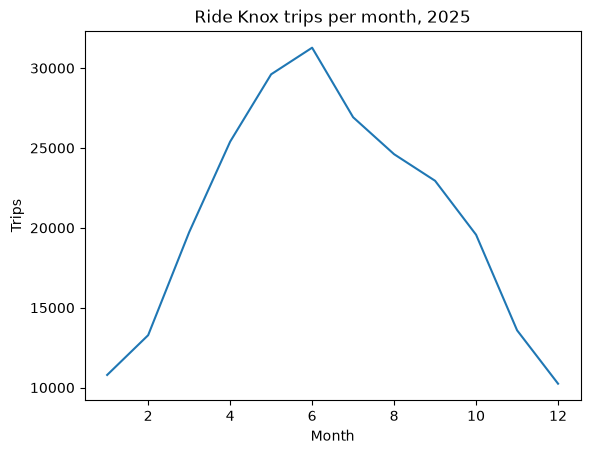

In [41]:
import matplotlib.pyplot as plt

monthly_total = trips.groupby("month").size()
# monthly_total
plt.plot(monthly_total.index, monthly_total.values)
plt.title("Ride Knox trips per month, 2025")
plt.xlabel("Month")
plt.ylabel("Trips")
plt.show()

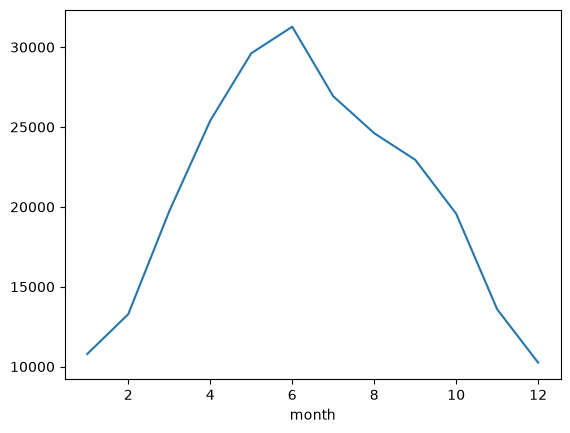

In [40]:
monthly_total.plot(); 

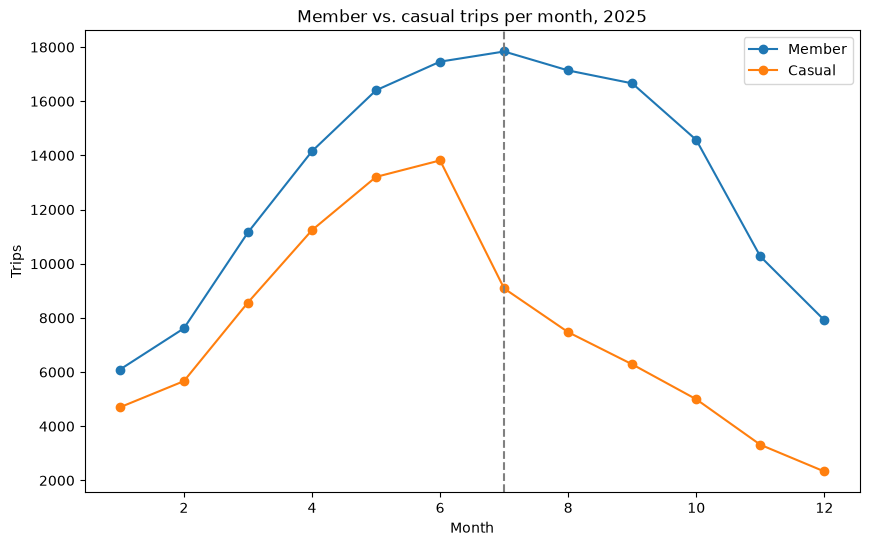

In [85]:
# plt.figure(figsize=(10, 6))
monthly = trips.groupby(["month", "rider_type"]).size().unstack()
plt.plot(monthly.index, monthly["member"], label="Member", marker="o")
plt.plot(monthly.index, monthly["casual"], label="Casual", marker="o")
# plt.plot(monthly_total.index, monthly_total.values, label="Together", marker="s")
plt.axvline(x=7, linestyle="--", color="gray")   					# July 1 price change
# plt.axhline
plt.title("Member vs. casual trips per month, 2025")
plt.xlabel("Month"); plt.ylabel("Trips"); plt.legend()
# plt.savefig("monthly_by_rider_type.png", dpi=150, bbox_inches="tight")
plt.show()

Text(0, 0.5, 'Number of trips')

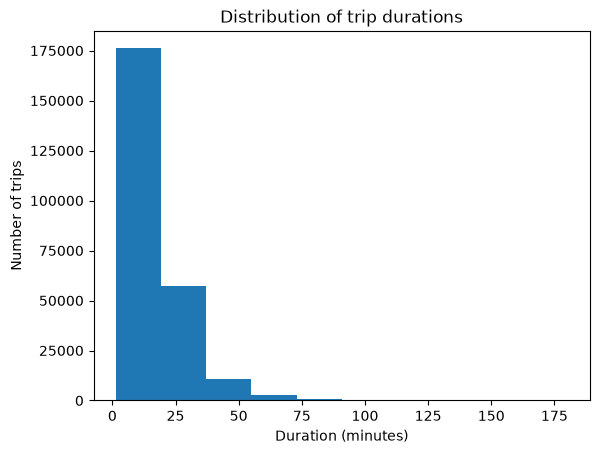

In [81]:
plt.hist(trips["duration_min"], bins=10)
# plt.hist(trips["duration_min"], bins=50)
# plt.hist(trips["duration_min"], bins=100)
plt.title("Distribution of trip durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")

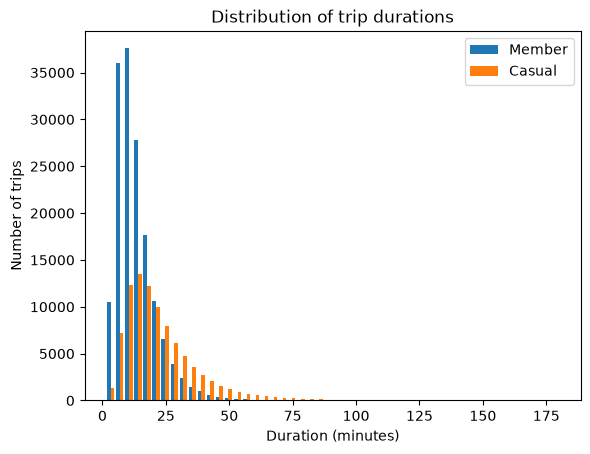

In [67]:
member_durations = trips.loc[trips['rider_type'] == 'member', 'duration_min']
casual_durations = trips.loc[trips['rider_type'] == 'casual', 'duration_min']

# plt.hist(member_durations, bins=50)
# plt.hist(casual_durations, bins=50)
# plt.hist([member_durations, casual_durations], bins=50)
plt.hist([member_durations, casual_durations], bins=50, label=['Member', 'Casual'])
plt.title("Distribution of trip durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")
plt.legend()
plt.show()

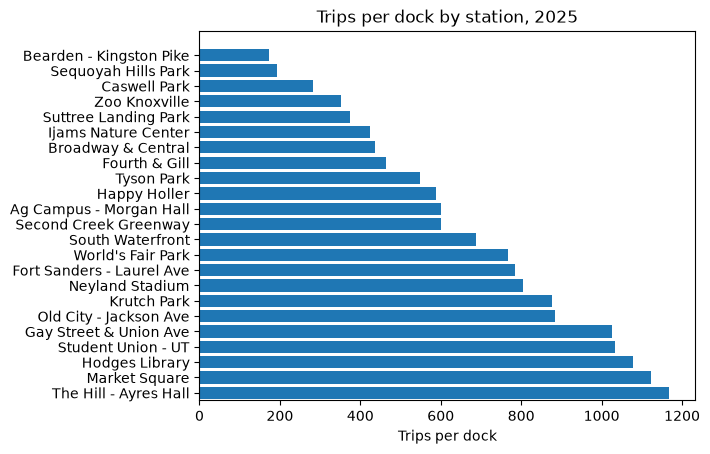

In [77]:
top = per_station.sort_values("trips_per_dock", ascending=False)
# top
plt.barh(top["station_name"], top["trips_per_dock"])
plt.title("Trips per dock by station, 2025")
plt.xlabel("Trips per dock")
# plt.gca().invert_yaxis()   # busiest at the top
# plt.ylim(bottom=0.5)
# plt.show()